This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

(a) Produce some numerical and graphical summaries of the Weekly
data. Do there appear to be any patterns?

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Weekly.csv')
print(data.info())
print(data.describe(include='all'))

print(data['Direction'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB
None
               Year         Lag1         Lag2         Lag3         Lag4  \
count   1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN   
mean    200

In [3]:
num_cols = data.select_dtypes(include='number')
print(num_cols.corr())

            Year      Lag1      Lag2      Lag3      Lag4      Lag5    Volume  \
Year    1.000000 -0.032289 -0.033390 -0.030006 -0.031128 -0.030519  0.841942   
Lag1   -0.032289  1.000000 -0.074853  0.058636 -0.071274 -0.008183 -0.064951   
Lag2   -0.033390 -0.074853  1.000000 -0.075721  0.058382 -0.072499 -0.085513   
Lag3   -0.030006  0.058636 -0.075721  1.000000 -0.075396  0.060657 -0.069288   
Lag4   -0.031128 -0.071274  0.058382 -0.075396  1.000000 -0.075675 -0.061075   
Lag5   -0.030519 -0.008183 -0.072499  0.060657 -0.075675  1.000000 -0.058517   
Volume  0.841942 -0.064951 -0.085513 -0.069288 -0.061075 -0.058517  1.000000   
Today  -0.032460 -0.075032  0.059167 -0.071244 -0.007826  0.011013 -0.033078   

           Today  
Year   -0.032460  
Lag1   -0.075032  
Lag2    0.059167  
Lag3   -0.071244  
Lag4   -0.007826  
Lag5    0.011013  
Volume -0.033078  
Today   1.000000  


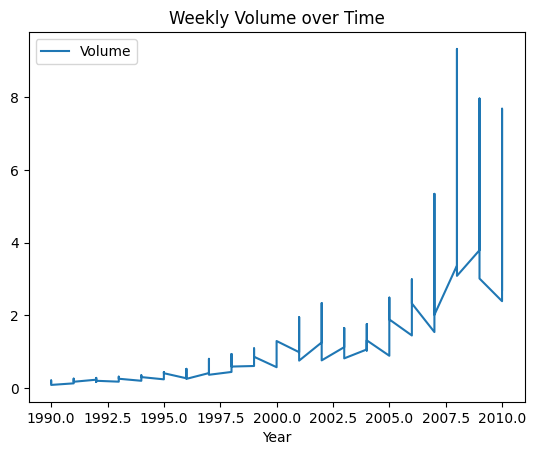

In [4]:
data.plot(x='Year', y='Volume', kind='line', title='Weekly Volume over Time')
plt.show()

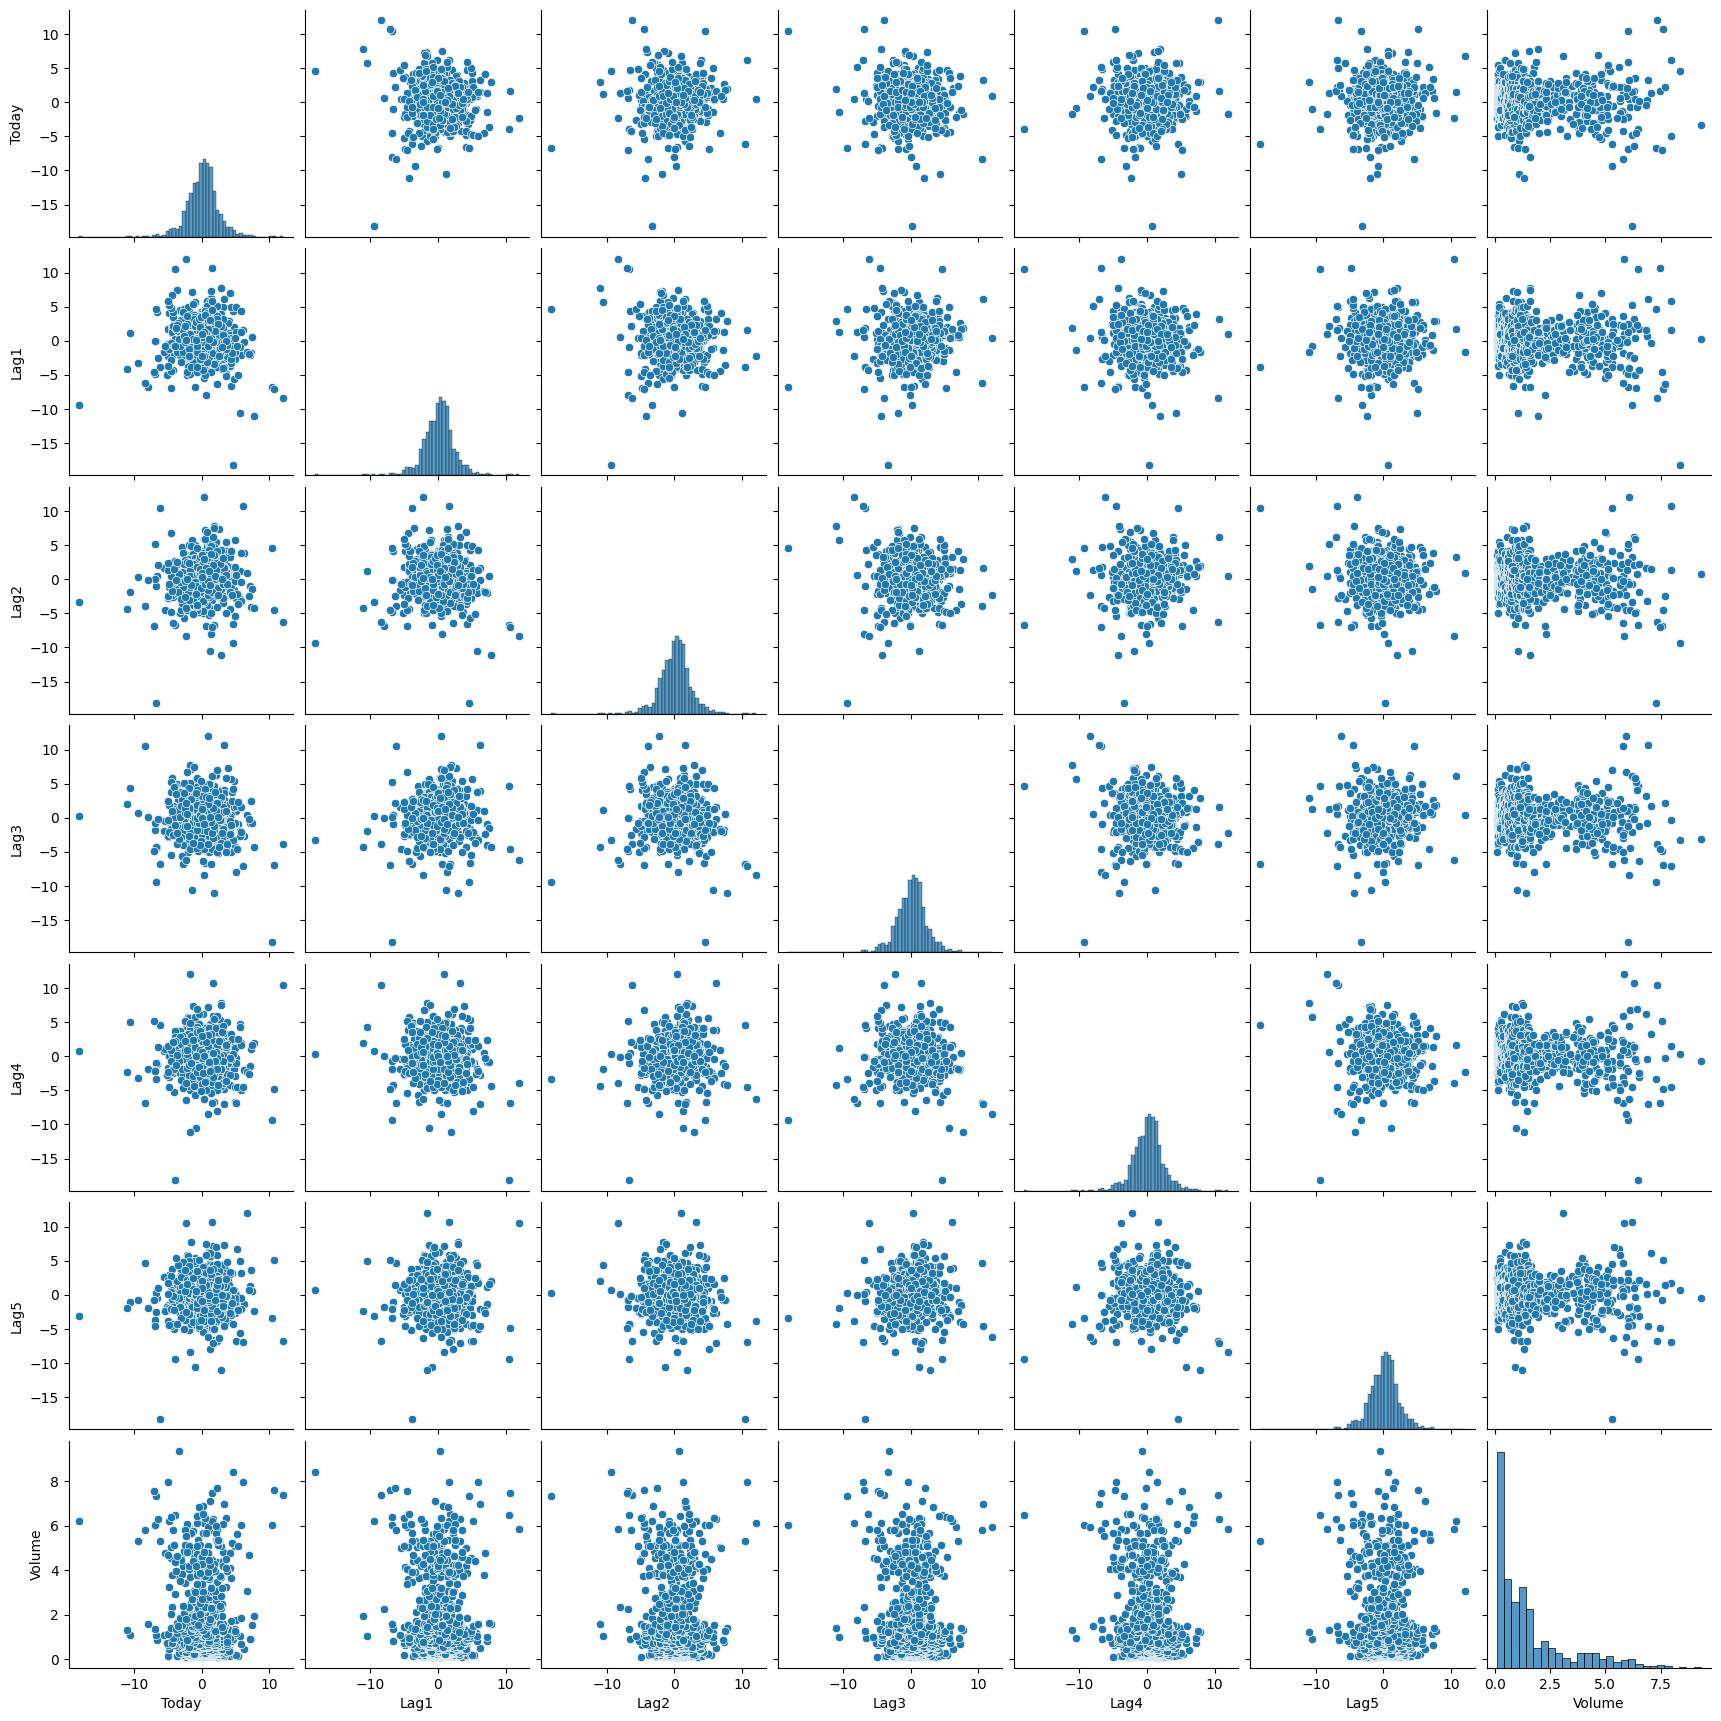

In [7]:
sns.pairplot(data[['Today','Lag1','Lag2','Lag3','Lag4','Lag5','Volume']])
plt.show()

Trading volume shows a clear upward trend over the years.


The correlations between the lagged returns and Today are all small.


(b) Use the full data set to perform a logistic regression with
Direction as the response and the five lag variables plus Volume
as predictors. Use the summary function to print the results. Do
any of the predictors appear to be statistically significant? If so,
which ones?

In [10]:
import statsmodels.api as sm

df = data.copy()
df['DirectionBin'] = (df['Direction'] == 'Up').astype(int)

X = df[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X = sm.add_constant(X)
y = df['DirectionBin']

# logistic regression
logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())

# p < 0.05
print("\nSignificant (p<0.05):")
print(result.pvalues[result.pvalues < 0.05])

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:           DirectionBin   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                0.006580
Time:                        15:13:05   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

Lag2 is statistically significant at the 5% level.

(c) Compute the confusion matrix and overall fraction of correct
predictions. Explain what the confusion matrix is telling you
about the types of mistakes made by logistic regression.

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

p_up = result.predict()

y_pred = (p_up >= 0.5).astype(int)
y_true = df['DirectionBin'].values  # Up=1, Down=0

# confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
cm_df = pd.DataFrame(cm, index=['Actual:Down','Actual:Up'],
                        columns=['Pred:Down','Pred:Up'])
# Transpose the DataFrame to reverse the axes
cm_df = cm_df.T
print(cm_df)

acc = accuracy_score(y_true, y_pred)
print(f'Overall accuracy = {acc:.4f}')

           Actual:Down  Actual:Up
Pred:Down           54         48
Pred:Up            430        557
Overall accuracy = 0.5611


The model tends to predict Up

(d) Now fit the logistic regression model using a training data period
from 1990 to 2008, with Lag2 as the only predictor. Compute the
confusion matrix and the overall fraction of correct predictions
for the held out data (that is, the data from 2009 and 2010).

In [37]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

train = df[df['Year'] <= 2008]
test  = df[df['Year'] >= 2009]

X_tr = sm.add_constant(train[['Lag2']])
y_tr = train['DirectionBin']
X_te = sm.add_constant(test[['Lag2']])
y_te = test['DirectionBin']

model = sm.Logit(y_tr, X_tr).fit()
print(model.summary())

p_up = model.predict(X_te)
y_pred = (p_up >= 0.5).astype(int)

cm = confusion_matrix(y_te, y_pred, labels=[0,1])   # rows=Actual(Down,Up), cols=Pred(Down,Up)
cm_df = pd.DataFrame(cm, index=['Actual:Down','Actual:Up'],
                       columns=['Pred:Down','Pred:Up'])
# Transpose the DataFrame to reverse the axes
cm_df = cm_df.T
print(cm_df)
acc = accuracy_score(y_te, y_pred)

print(f'Overall accuracy = {acc:.4f}')

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:           DirectionBin   No. Observations:                  985
Model:                          Logit   Df Residuals:                      983
Method:                           MLE   Df Model:                            1
Date:                Sat, 01 Nov 2025   Pseudo R-squ.:                0.003076
Time:                        16:31:26   Log-Likelihood:                -675.27
converged:                       True   LL-Null:                       -677.35
Covariance Type:            nonrobust   LLR p-value:                   0.04123
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2033      0.064      3.162      0.002       0.077       0.329
Lag2           0.0581      0.